In [464]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load dataset

In [465]:
df = pd.read_csv('formatted_data.csv')
df.head()

,Brand,Model,YOM,Mileage,Gear,Fuel Type,Engine (cc),Condition,Ad Date,Location,...,Number of Cylinders,Power Steering,Power Shutters,Power Mirrors,Manufacturing Country,Model_cleaned,Mileage_numeric,Price_numeric,Ad_Date_Clean_Str,Ad_Date_clean
0,Audi,A3 Sline,2018,93000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jun 05, 11:39 am",Colombo,...,3.0,Yes,Yes,Yes,Germany,a3sline,93000.0,14400000.0,2026 Jun 05,2026-06-05
1,Audi,A1 Sline,2017,96000.0,Automatic,Petrol,990.0,Registered (Used),"2026 Jun 06, 10:27 pm",Kandy,...,3.0,Yes,Yes,Yes,Germany,a1sline,96000.0,8650000.0,2026 Jun 06,2026-06-06
2,Audi,A1 Highest Spec,2016,86000.0,Automatic,Petrol,10000.0,Registered (Used),"2026 Jul 19, 9:58 am",Colombo,...,6.0,Yes,Yes,Yes,Germany,a1highestspec,86000.0,8200000.0,2026 Jul 19,2026-07-19
3,Audi,A1,2017,69000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 27, 5:36 pm",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,69000.0,8700000.0,2026 Jul 27,2026-07-27
4,Audi,A1,2016,55000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 28, 12:06 am",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,55000.0,9500000.0,2026 Jul 28,2026-07-28


In [466]:
# 1. Filter engine and condition first
df = df[
    (df['Engine (cc)'] < 10000) &
    (df['Condition'] != 'Antique')
].copy()

# 2. Count models AFTER the above filtering
model_counts = df['Model_cleaned'].value_counts()

# 3. Keep only models with at least 2 rows
df = df[
    df['Model_cleaned'].isin(model_counts[model_counts >= 2].index)
].copy()

# 4. Check the result
print(df['Model_cleaned'].value_counts())

Model_cleaned
prius                 163
vitz                  163
premio                158
yaris                 157
aqua                  147
                     ... 
raize12lz               2
raizeturbo              2
320de46                 2
a3urbanstyle            2
a3slinehighestspec      2
Name: count, Length: 420, dtype: int64


In [467]:
print(df['Model_cleaned'].value_counts())

Model_cleaned
prius                 163
vitz                  163
premio                158
yaris                 157
aqua                  147
                     ... 
raize12lz               2
raizeturbo              2
320de46                 2
a3urbanstyle            2
a3slinehighestspec      2
Name: count, Length: 420, dtype: int64


Data cleaning


In [468]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5753 entries, 0 to 6433
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  5753 non-null   object 
 1   Model                  5753 non-null   object 
 2   YOM                    5753 non-null   int64  
 3   Mileage                5739 non-null   float64
 4   Gear                   5753 non-null   object 
 5   Fuel Type              5753 non-null   object 
 6   Engine (cc)            5753 non-null   float64
 7   Condition              5753 non-null   object 
 8   Ad Date                5753 non-null   object 
 9   Location               5753 non-null   object 
 10  Price                  5753 non-null   object 
 11  URL                    5753 non-null   object 
 12  Body Type              5753 non-null   object 
 13  Number of Cylinders    5564 non-null   float64
 14  Power Steering         5753 non-null   object 
 15  Power Shu

In [469]:
df.drop_duplicates(inplace=True)

In [470]:
df['Price_numeric'].isna().sum()

np.int64(1282)

In [471]:
df.dropna(subset=['Price_numeric'], inplace=True)
df['Price_numeric'].isna().sum()

np.int64(0)

In [472]:
df['Mileage_numeric'].isna().sum()

np.int64(6)

In [473]:
df.dropna(subset=['Mileage_numeric'], inplace=True)
df['Mileage_numeric'].isna().sum()

np.int64(0)

In [474]:
df['Number of Cylinders'].isna().sum()

np.int64(156)

In [475]:
df.dropna(subset=['Number of Cylinders'], inplace=True)
df['Number of Cylinders'].isna().sum()

np.int64(0)

In [476]:
df['Power Shutters'].isna().sum()

np.int64(0)

In [477]:
df['Power Mirrors'].isna().sum()

np.int64(0)

In [478]:
df['Engine (cc)'].isna().sum()

np.int64(0)

In [479]:
df.dropna(subset=['Engine (cc)'], inplace=True)
df['Engine (cc)'].isna().sum()

np.int64(0)

In [480]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4309 entries, 0 to 6433
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  4309 non-null   object 
 1   Model                  4309 non-null   object 
 2   YOM                    4309 non-null   int64  
 3   Mileage                4309 non-null   float64
 4   Gear                   4309 non-null   object 
 5   Fuel Type              4309 non-null   object 
 6   Engine (cc)            4309 non-null   float64
 7   Condition              4309 non-null   object 
 8   Ad Date                4309 non-null   object 
 9   Location               4309 non-null   object 
 10  Price                  4309 non-null   object 
 11  URL                    4309 non-null   object 
 12  Body Type              4309 non-null   object 
 13  Number of Cylinders    4309 non-null   float64
 14  Power Steering         4309 non-null   object 
 15  Power Shu

In [481]:
print(df.describe())

               YOM        Mileage  Engine (cc)  Number of Cylinders  \
count  4309.000000    4309.000000   4309.00000          4309.000000   
mean   2011.828963  121702.307264   1345.38408             3.709677   
std       9.655137   73291.055716    428.68282             0.552660   
min    1973.000000       0.000000      1.00000             2.000000   
25%    2007.000000   75000.000000   1000.00000             3.000000   
50%    2014.000000  126000.000000   1490.00000             4.000000   
75%    2018.000000  169200.000000   1500.00000             4.000000   
max    2026.000000  856648.000000   3724.00000             8.000000   

       Mileage_numeric  Price_numeric  
count      4309.000000   4.309000e+03  
mean     121702.307264   9.306717e+06  
std       73291.055716   5.849770e+06  
min           0.000000   3.450000e+03  
25%       75000.000000   5.700000e+06  
50%      126000.000000   8.000000e+06  
75%      169200.000000   1.130000e+07  
max      856648.000000   6.500000e+07  


In [482]:
print((df['Engine (cc)'] > 10000).sum())

0


In [483]:
df.describe()

,YOM,Mileage,Engine (cc),Number of Cylinders,Mileage_numeric,Price_numeric
count,4309.000000,4309.000000,4309.00000,4309.000000,4309.000000,4.309000e+03
mean,2011.828963,121702.307264,1345.38408,3.709677,121702.307264,9.306717e+06
std,9.655137,73291.055716,428.68282,0.552660,73291.055716,5.849770e+06
min,1973.000000,0.000000,1.00000,2.000000,0.000000,3.450000e+03
25%,2007.000000,75000.000000,1000.00000,3.000000,75000.000000,5.700000e+06
50%,2014.000000,126000.000000,1490.00000,4.000000,126000.000000,8.000000e+06
75%,2018.000000,169200.000000,1500.00000,4.000000,169200.000000,1.130000e+07
max,2026.000000,856648.000000,3724.00000,8.000000,856648.000000,6.500000e+07


EDA

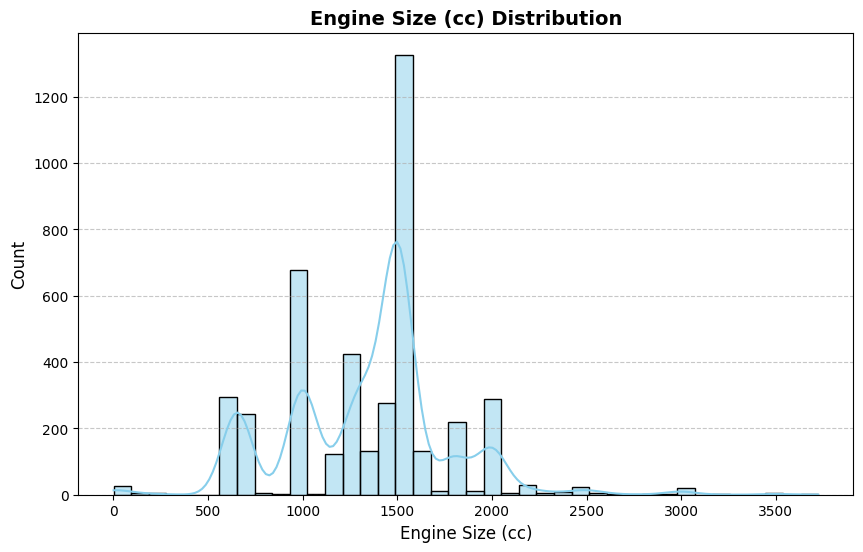

In [484]:
# 2. Set up the figure size for better readability
plt.figure(figsize=(10, 6))

# 3. Plot with increased bins and a KDE curve to show distribution shape
sns.histplot(
    data=df, 
    x="Engine (cc)", 
    bins=40,          # More bins give a finer, smoother look
    kde=True,         # Adds a density probability curve
    color="skyblue", 
    edgecolor="black"
)

# 4. Styling the plot
plt.title("Engine Size (cc) Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Engine Size (cc)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


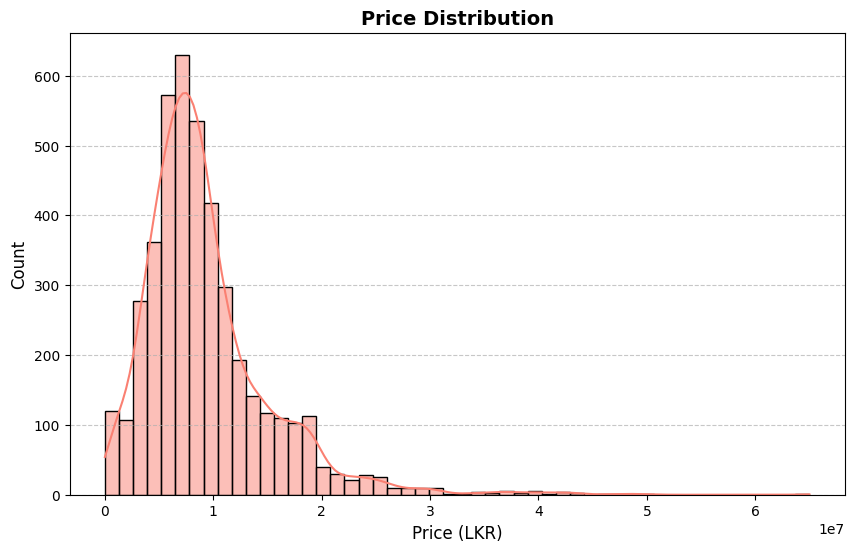

In [485]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Price_numeric",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Price (LKR)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

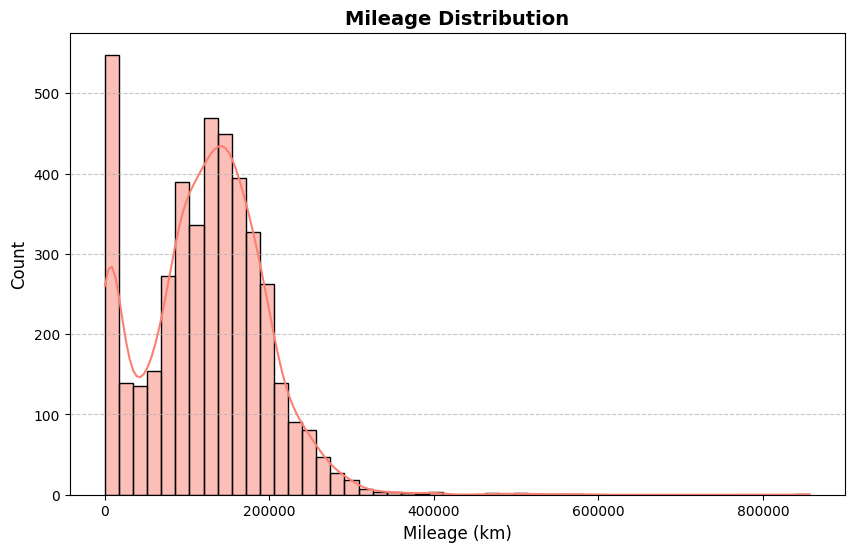

In [486]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Mileage_numeric",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Mileage Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Mileage (km)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

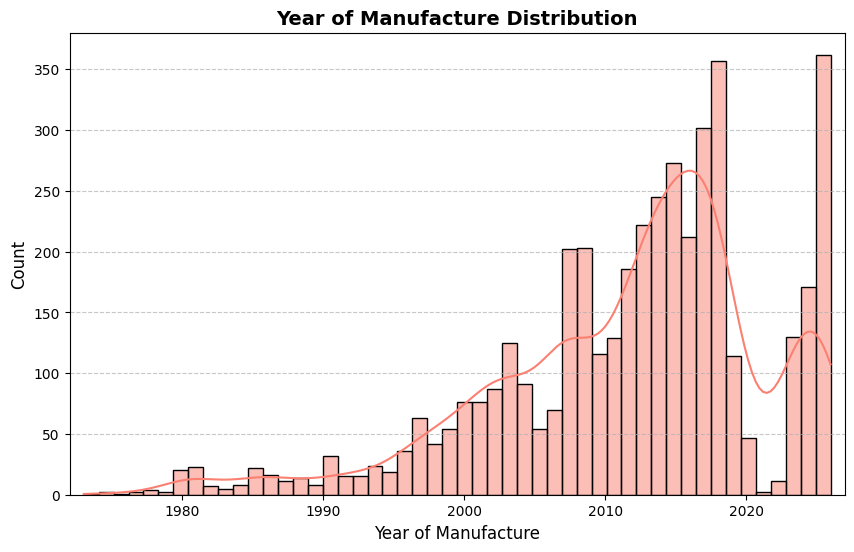

In [487]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="YOM",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Year of Manufacture Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Year of Manufacture", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xlim(df['YOM'].min() - 1, df['YOM'].max() + 1)  # Adjust x-axis limits for better visualization
plt.show()

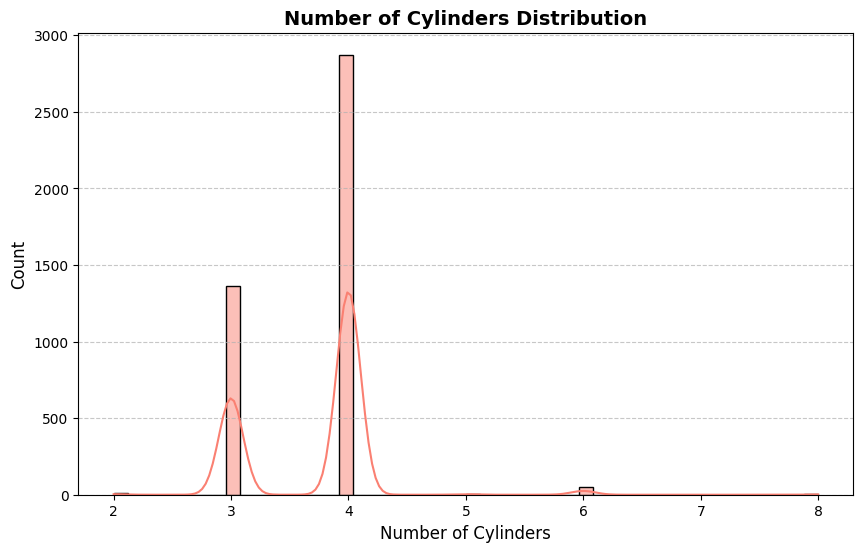

In [488]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Number of Cylinders",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Number of Cylinders Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

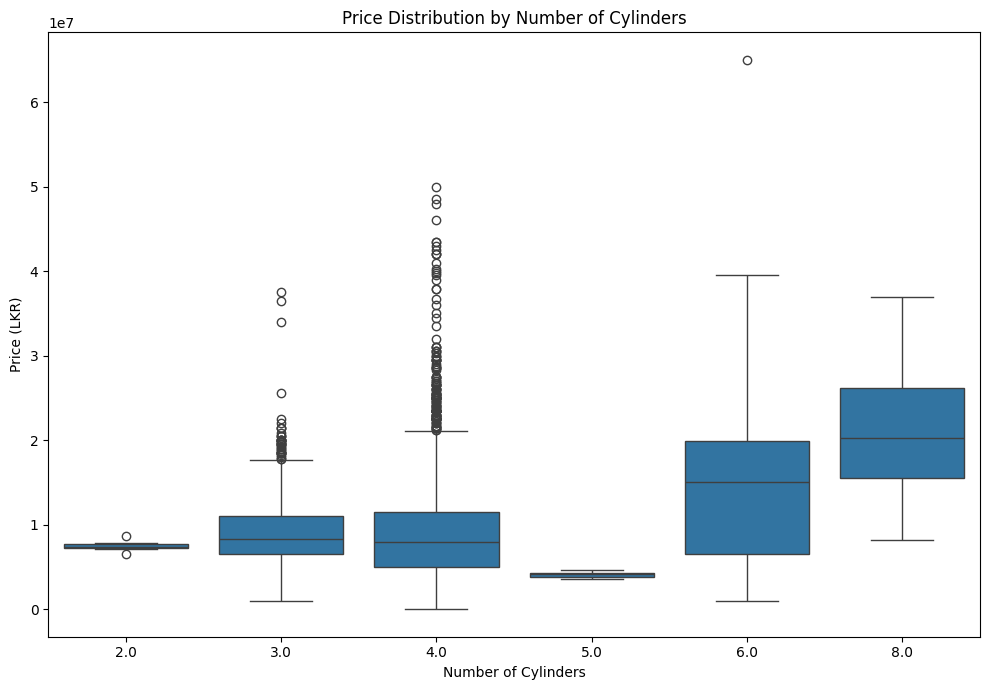

In [489]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Number of Cylinders',
    y='Price_numeric'
)

plt.title('Price Distribution by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

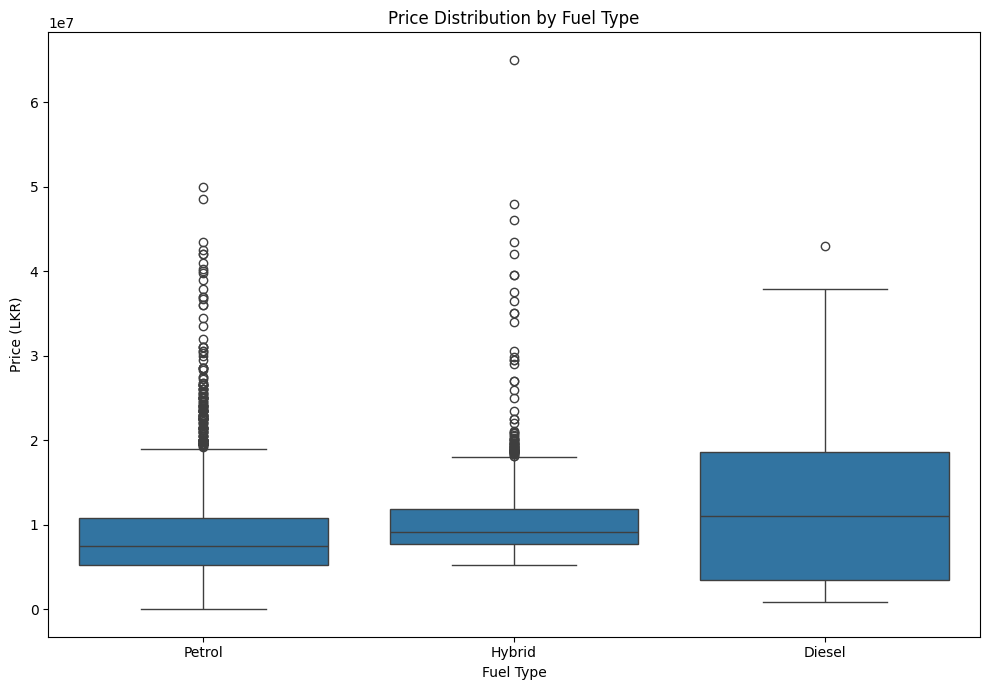

In [490]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Fuel Type',
    y='Price_numeric'
)

plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

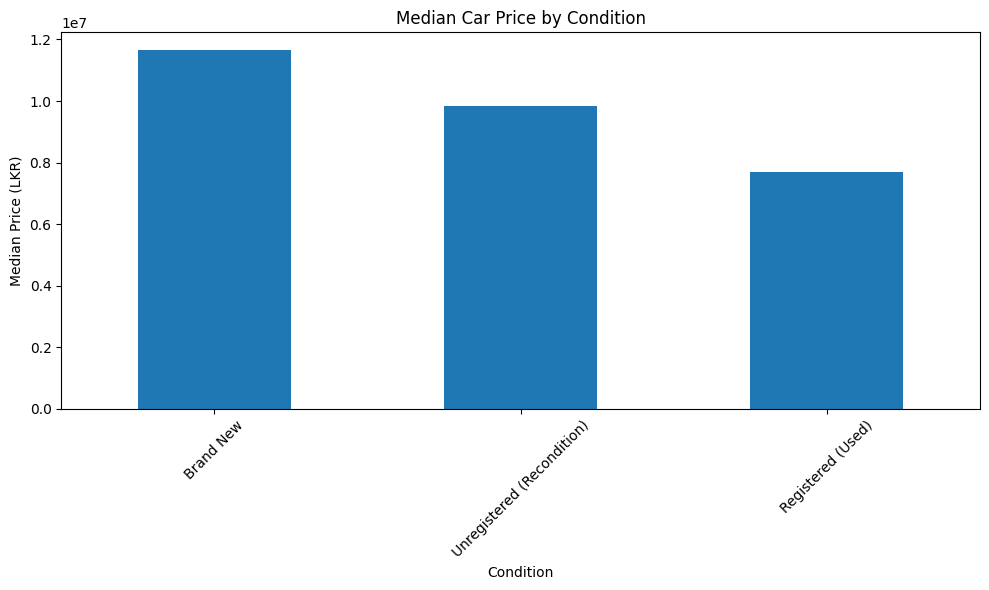

In [491]:
condition_price = (
    df.groupby('Condition')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

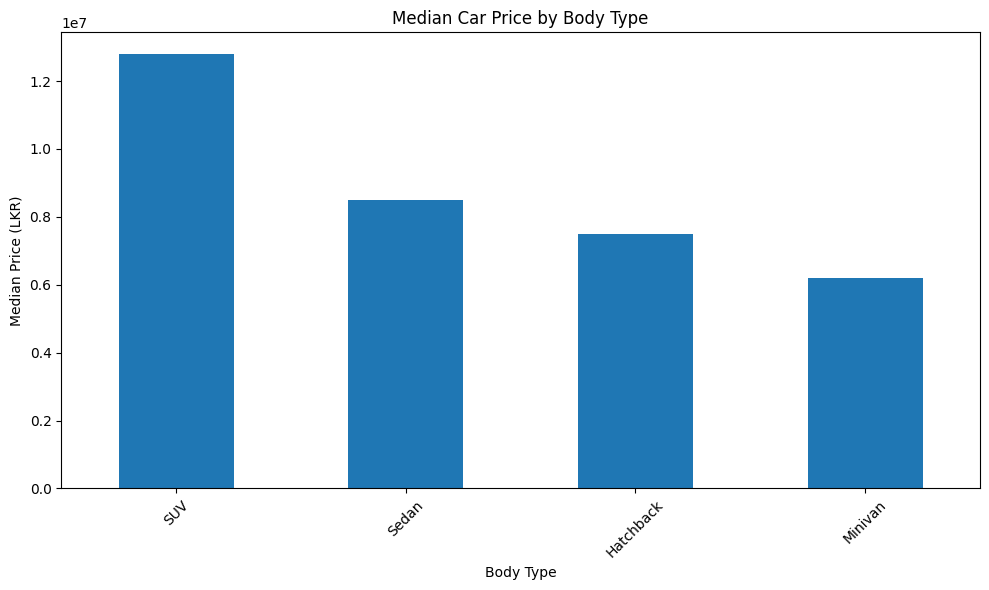

In [492]:
condition_price = (
    df.groupby('Body Type')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

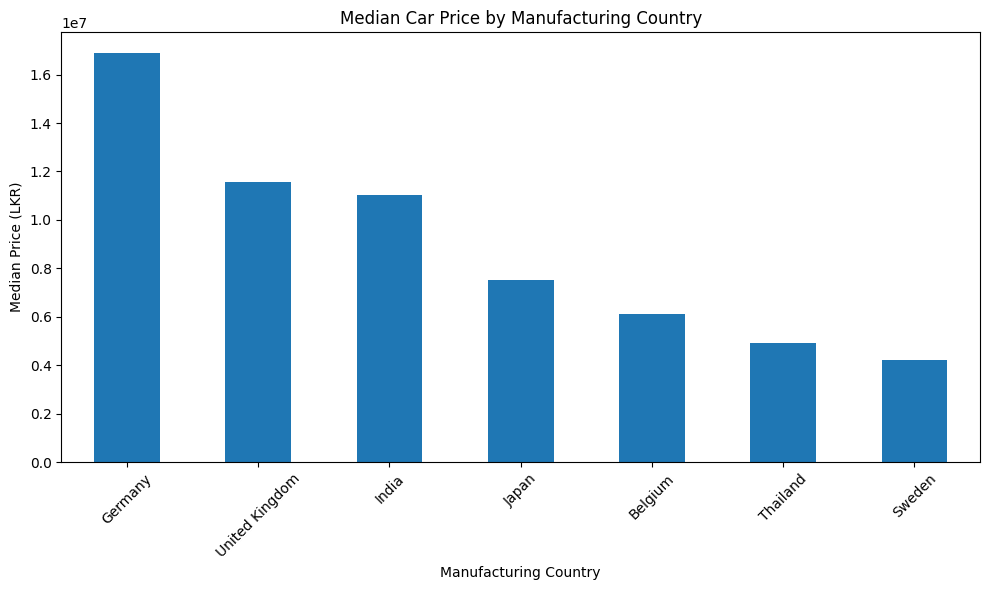

In [493]:
condition_price = (
    df.groupby('Manufacturing Country')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Manufacturing Country')
plt.xlabel('Manufacturing Country')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

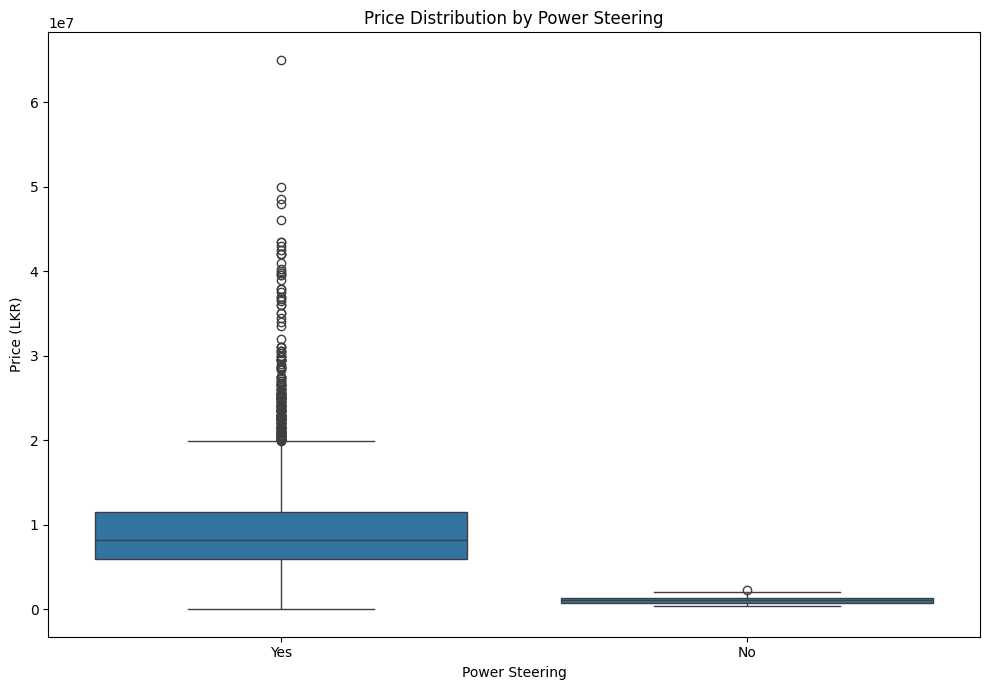

In [494]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Steering',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Steering')
plt.xlabel('Power Steering')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

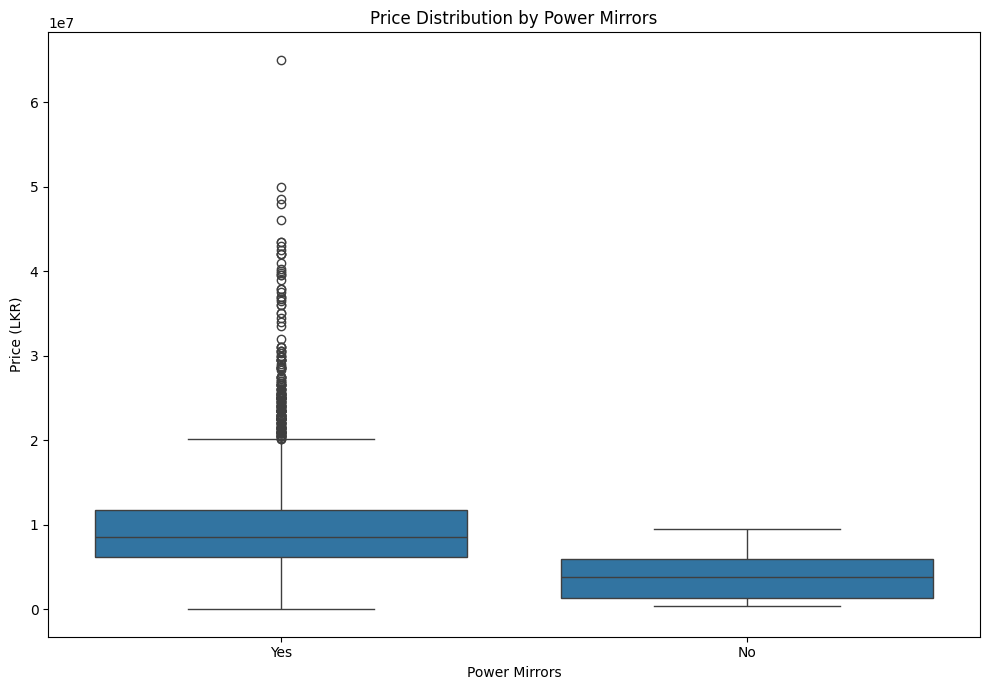

In [495]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Mirrors',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Mirrors')
plt.xlabel('Power Mirrors')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

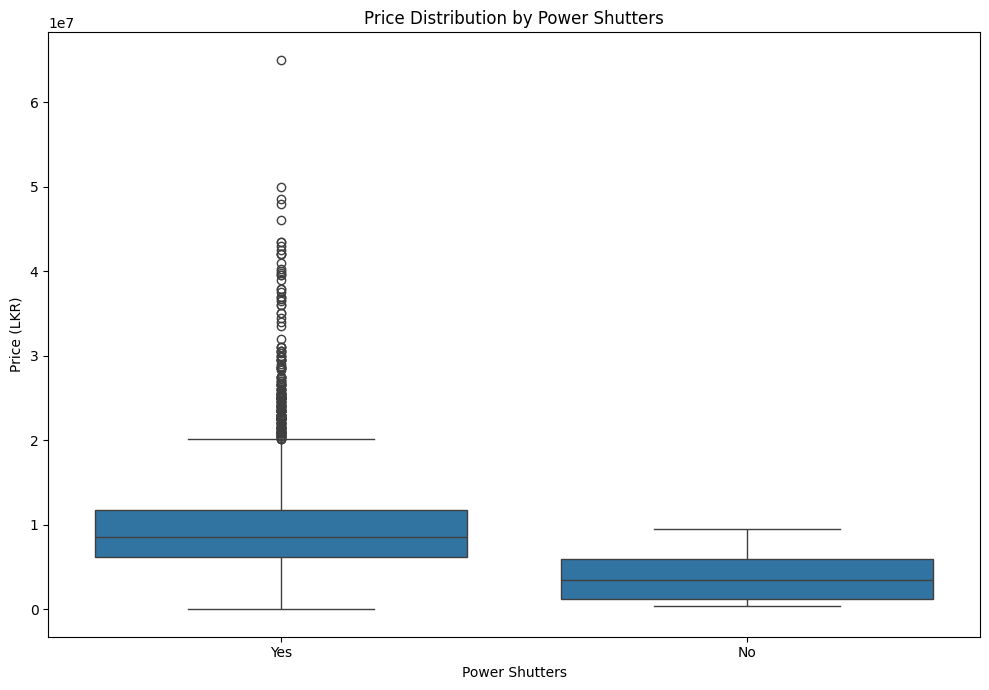

In [496]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Shutters',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Shutters')
plt.xlabel('Power Shutters')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

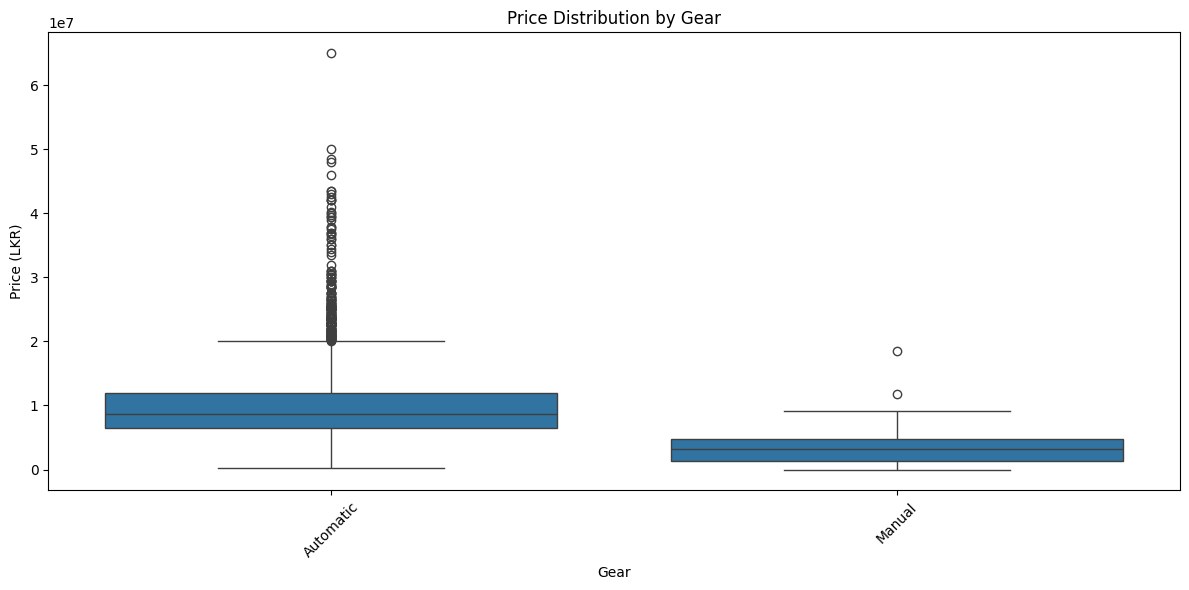

In [497]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Gear',
    y='Price_numeric'
)

plt.title('Price Distribution by Gear')
plt.xlabel('Gear')
plt.ylabel('Price (LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

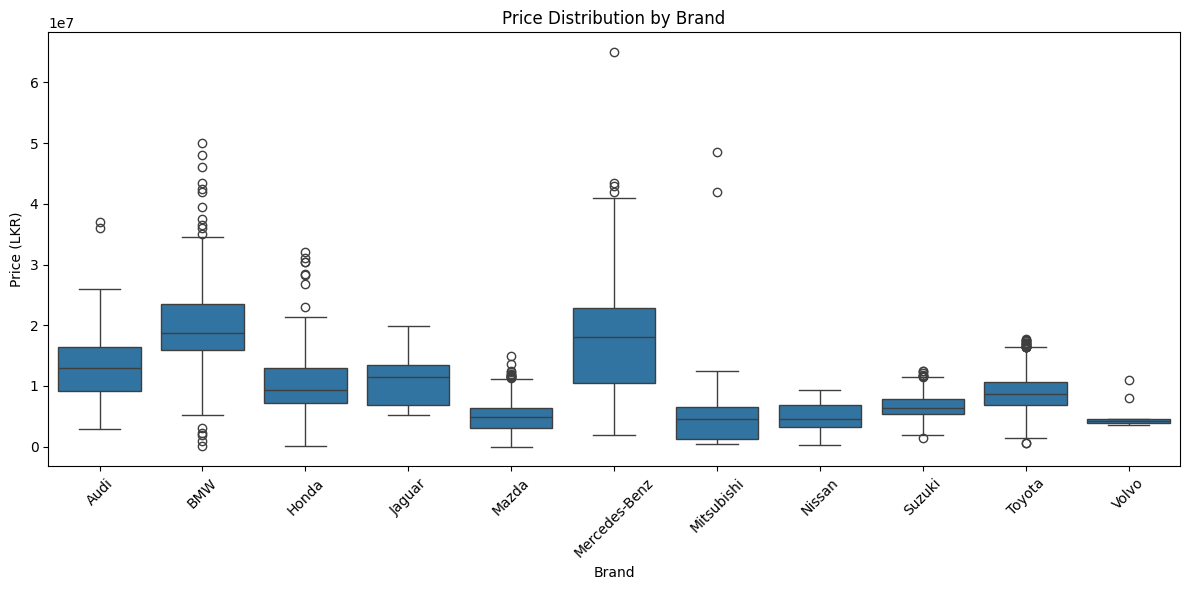

In [498]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Brand',
    y='Price_numeric'
)

plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price (LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

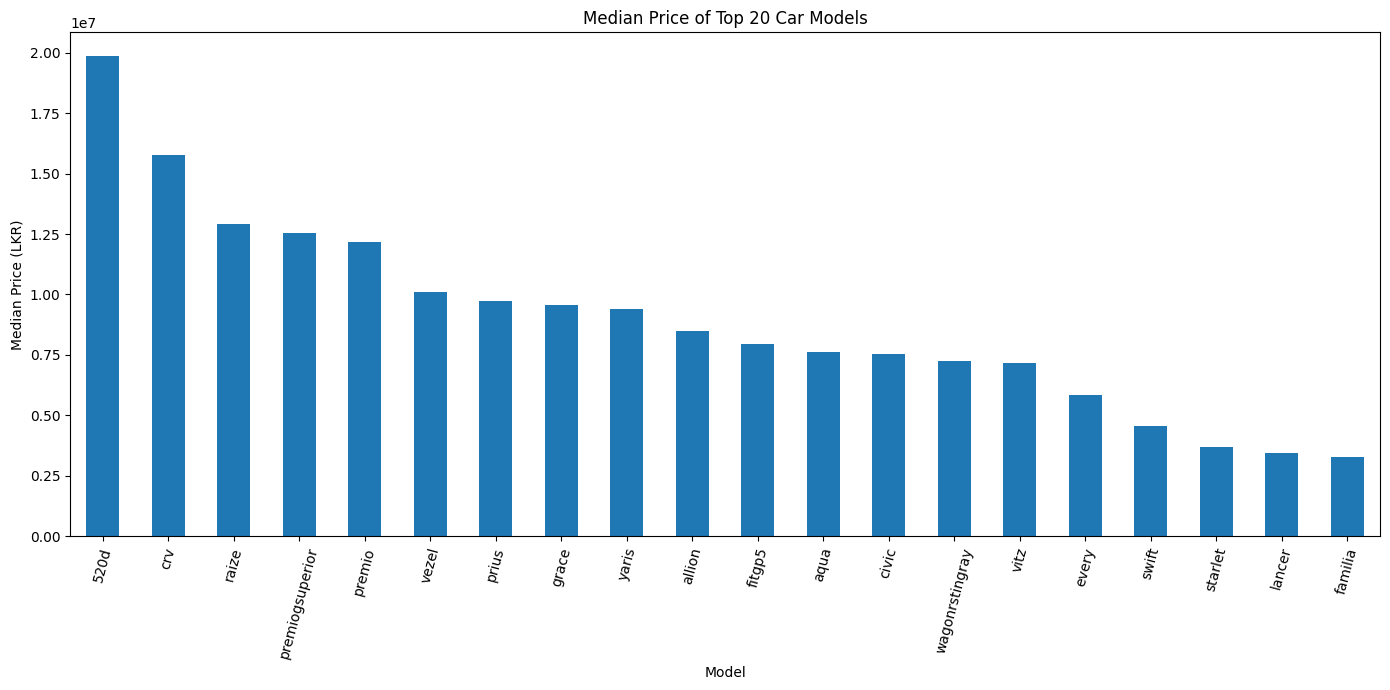

In [499]:
top_models = df['Model_cleaned'].value_counts().head(20).index
model_price = (
    df[df['Model_cleaned'].isin(top_models)]
    .groupby('Model_cleaned')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
model_price.plot(kind='bar')

plt.title('Median Price of Top 20 Car Models')
plt.xlabel('Model')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

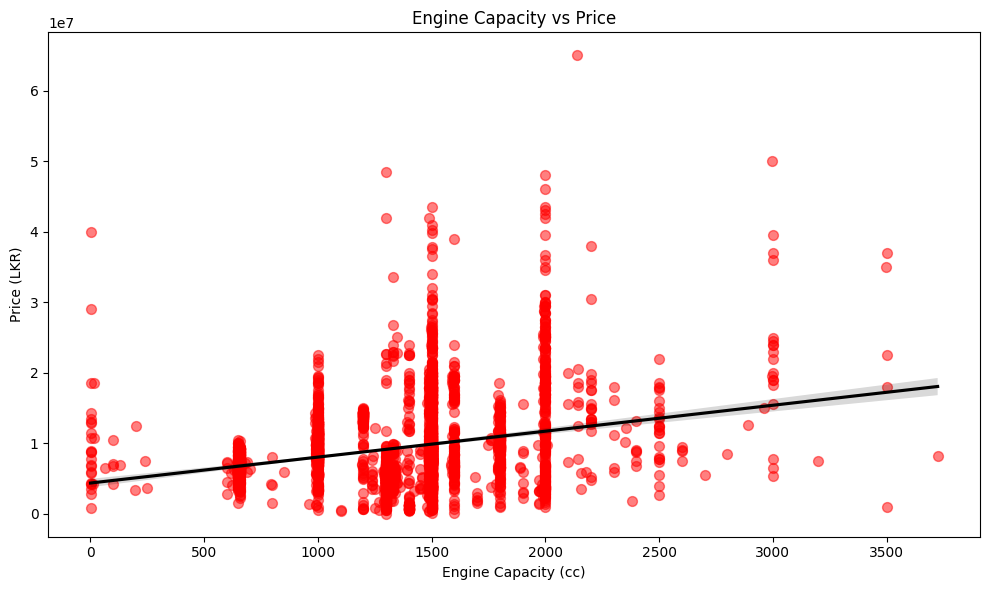

In [500]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Engine (cc)',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'s':50,'color': 'red'},
    line_kws={'color': 'black'}

)

plt.title('Engine Capacity vs Price')
plt.xlabel('Engine Capacity (cc)')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

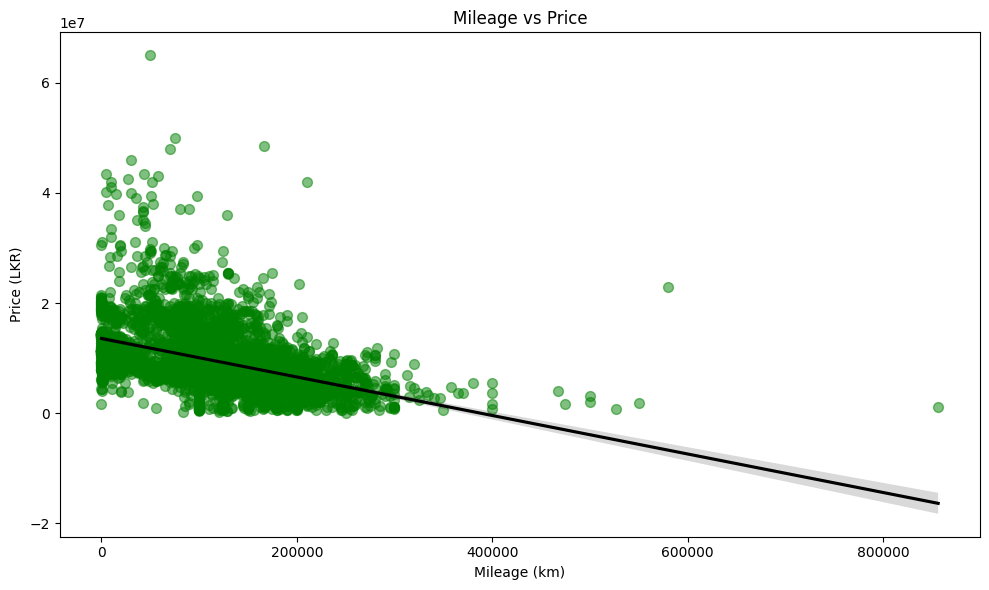

In [501]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Mileage_numeric',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Mileage vs Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

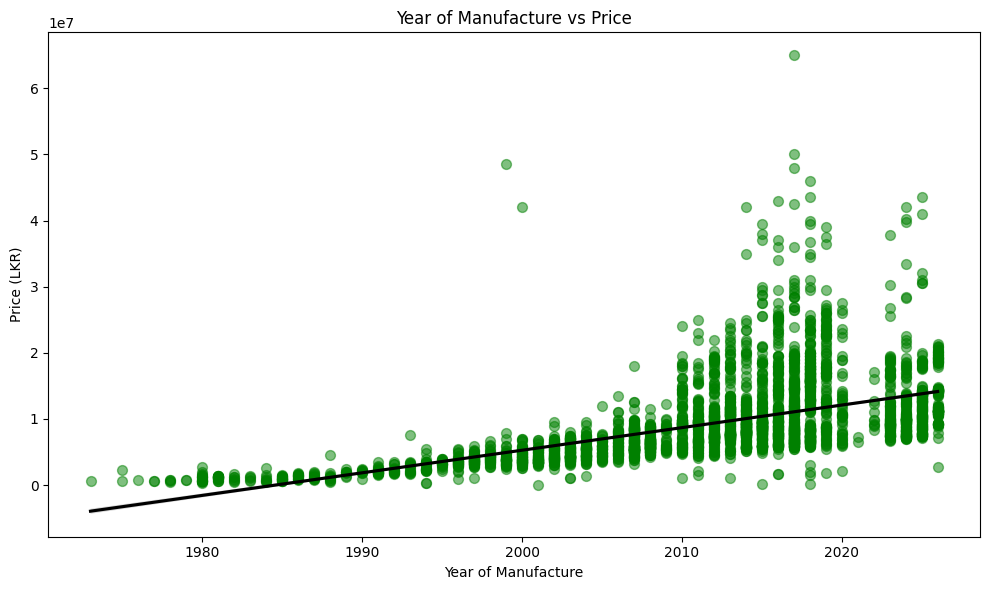

In [502]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='YOM',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Year of Manufacture vs Price')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.show()

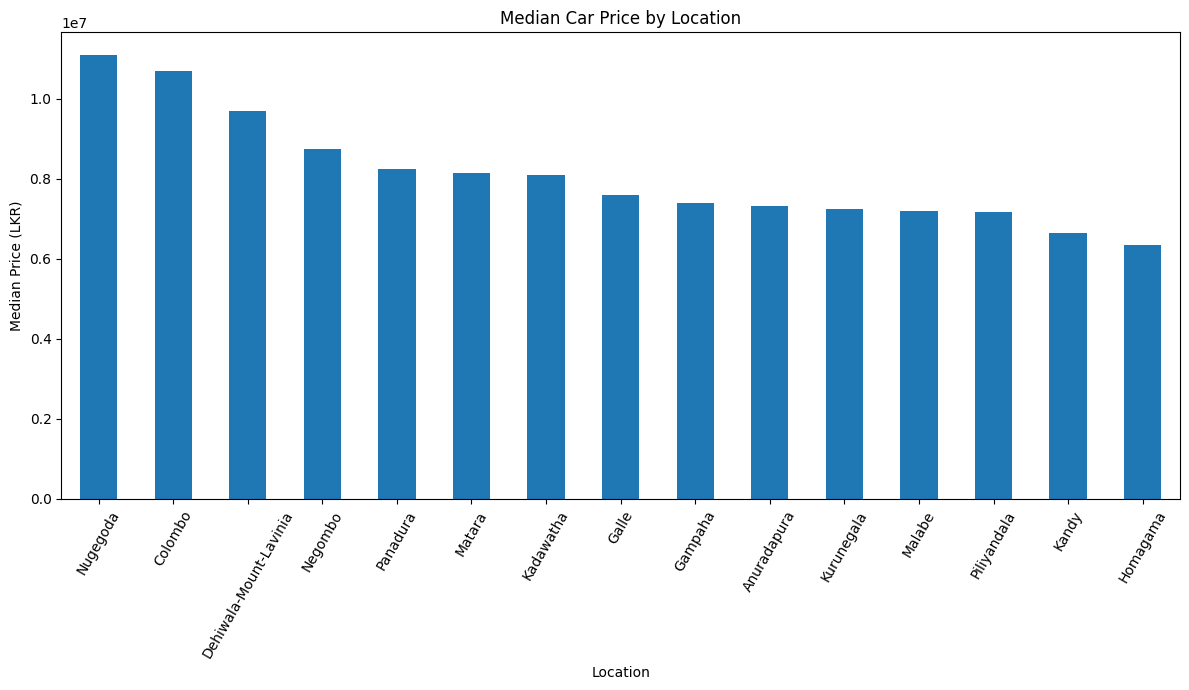

In [503]:
top_locations = df['Location'].value_counts().head(15).index
location_price = (
    df[df['Location'].isin(top_locations)]
    .groupby('Location')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

location_price.plot(kind='bar')

plt.title('Median Car Price by Location')
plt.xlabel('Location')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

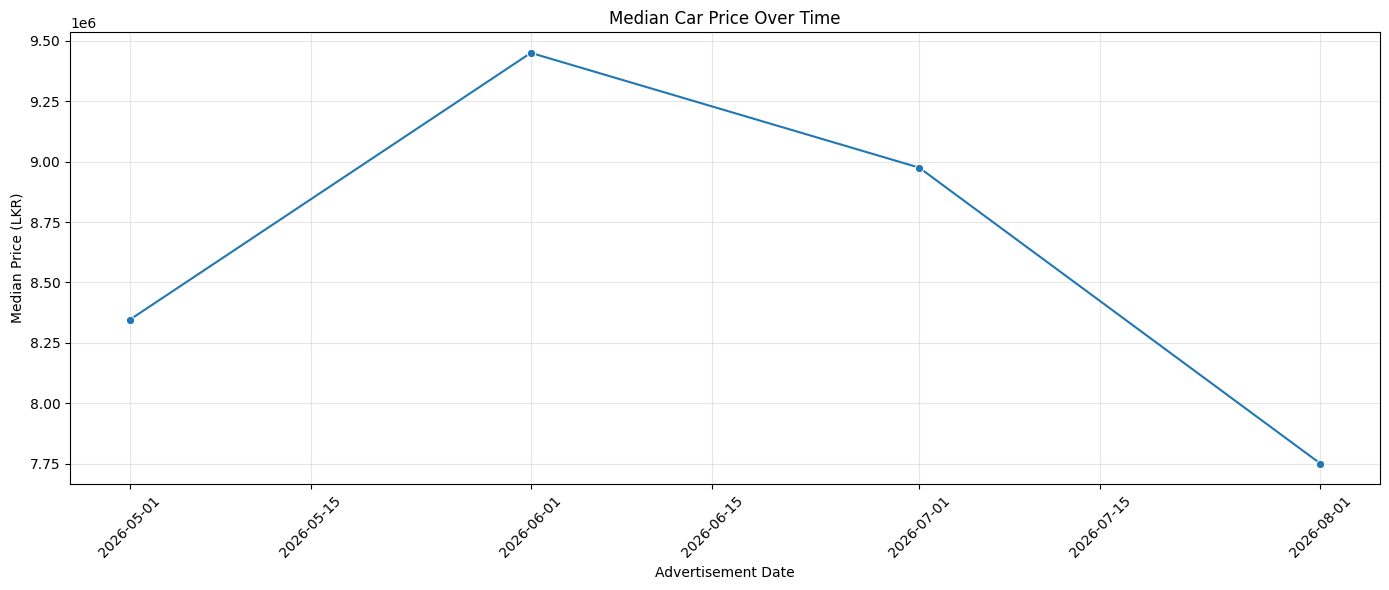

In [504]:
df['Ad_Date_clean_dt'] = pd.to_datetime(df['Ad_Date_clean'], errors='coerce')
df['Ad_Month'] = df['Ad_Date_clean_dt'].dt.to_period('M')

monthly_price = (
    df.groupby('Ad_Month')['Price_numeric']
      .median()
      .reset_index()
)

monthly_price['Ad_Month'] = monthly_price['Ad_Month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_price,
    x='Ad_Month',
    y='Price_numeric',
    marker='o'
)

plt.title('Median Car Price Over Time')
plt.xlabel('Advertisement Date')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

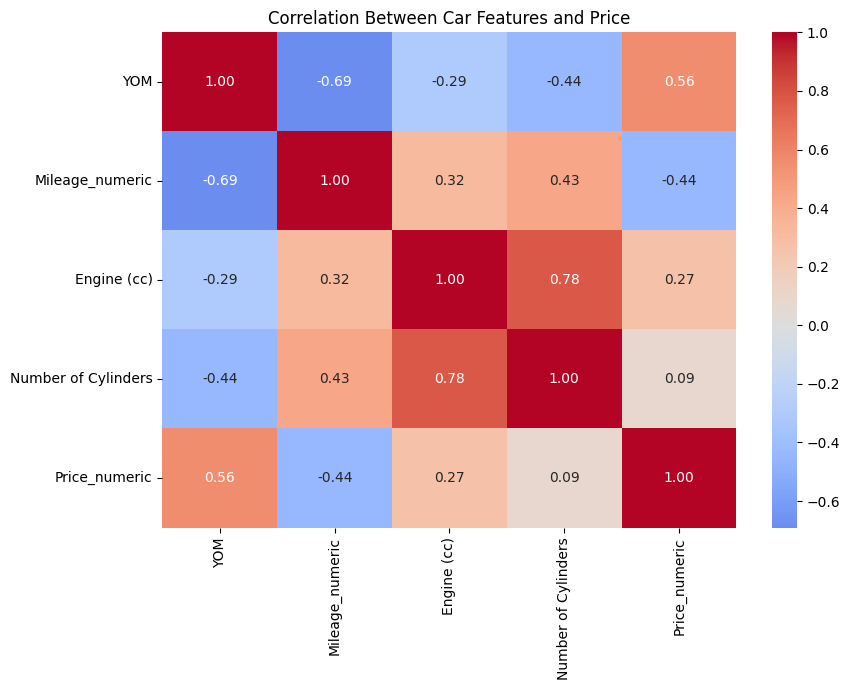

In [505]:
numeric_cols = [
    'YOM',
    'Mileage_numeric',
    'Engine (cc)',
    'Number of Cylinders',
    'Price_numeric'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Car Features and Price')
plt.tight_layout()
plt.show()

Model Building


In [506]:
power_cols = [
    'Power Steering',
    'Power Shutters',
    'Power Mirrors'
]

for col in power_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            'yes': 1,
            'no': 0
        })
    )

In [507]:
features = [
    'Brand',
    'Model_cleaned',
    'YOM',
    'Mileage_numeric',
    'Gear',
    'Fuel Type',
    'Engine (cc)',
    'Number of Cylinders',
    'Condition',
    'Body Type',
    'Power Steering',
    'Power Mirrors',
    'Power Shutters']

x = df[features]
y = df['Price_numeric']



In [508]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4309 entries, 0 to 6433
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Brand                  4309 non-null   object        
 1   Model                  4309 non-null   object        
 2   YOM                    4309 non-null   int64         
 3   Mileage                4309 non-null   float64       
 4   Gear                   4309 non-null   object        
 5   Fuel Type              4309 non-null   object        
 6   Engine (cc)            4309 non-null   float64       
 7   Condition              4309 non-null   object        
 8   Ad Date                4309 non-null   object        
 9   Location               4309 non-null   object        
 10  Price                  4309 non-null   object        
 11  URL                    4309 non-null   object        
 12  Body Type              4309 non-null   object        
 13  Number o

In [509]:
print(x)

      Brand Model_cleaned   YOM  Mileage_numeric       Gear Fuel Type  \
0      Audi       a3sline  2018          93000.0  Automatic    Petrol   
1      Audi       a1sline  2017          96000.0  Automatic    Petrol   
3      Audi            a1  2017          69000.0  Automatic    Petrol   
4      Audi            a1  2016          55000.0  Automatic    Petrol   
5      Audi            a1  2016          67000.0  Automatic    Petrol   
...     ...           ...   ...              ...        ...       ...   
6429  Volvo           s80  1999         216000.0  Automatic    Petrol   
6430  Volvo           s80  2002         156000.0  Automatic    Petrol   
6431  Volvo           s80  2000         292000.0     Manual    Petrol   
6432  Volvo           s80  2002         199000.0     Manual    Petrol   
6433  Volvo           s80  2001         217000.0     Manual    Petrol   

      Engine (cc)  Number of Cylinders          Condition  Body Type  \
0          1000.0                  3.0  Registered 

In [510]:
print(df['Model_cleaned'].value_counts())

Model_cleaned
vitz              139
yaris             127
aqua              124
crv               118
swift             117
                 ... 
c180amg             1
c200amgpremium      1
c200amgline         1
raize1200           1
520dgt              1
Name: count, Length: 394, dtype: int64


In [512]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=df['Model_cleaned'])



ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.